In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.compat.v1 as tf1
tf.compat.v1.disable_v2_behavior() # 1.x 兼容模式
# TF 2.16+ disable_v2_behavior 不再导出 Session 等到顶层, 手动补上
tf.Session = tf1.Session
tf.placeholder = tf1.placeholder
tf.global_variables_initializer = tf1.global_variables_initializer
tf.Variable = tf1.Variable
tf.train = tf1.train
tf.layers = tf1.layers
tf.losses = tf1.losses


Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
np.random.seed(999)

In [4]:
def pre(x):
    return 2 * x + 3

In [5]:
x = 5*np.random.rand(500)
y = [pre(i) for i in x]
print(y[:10])

[11.034280400796879, 8.275222956826447, 4.19111465028212, 9.396814442423551, 3.9092526277407997, 6.322256807930123, 7.273809474413368, 8.543858124306526, 9.28126522477561, 9.973929441943483]


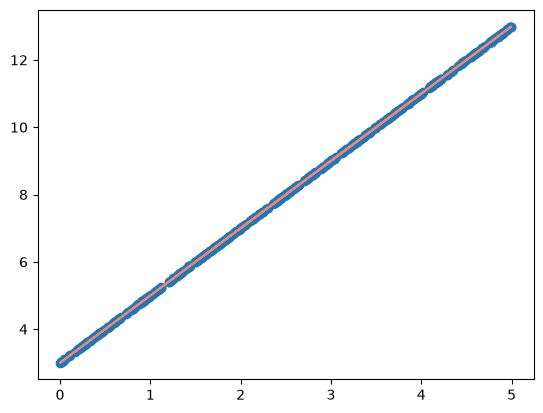

In [6]:
plt.plot(x,y,"salmon")
plt.scatter(x,y)
plt.show()
 


In [7]:
# 添加噪声
-0.5 + np.random.randn(1)

array([1.61082548])

In [8]:
x = [i-0.5 + np.random.random(1)[0] for i in x]
y = [i-0.5 + np.random.random(1)[0] for i in y]


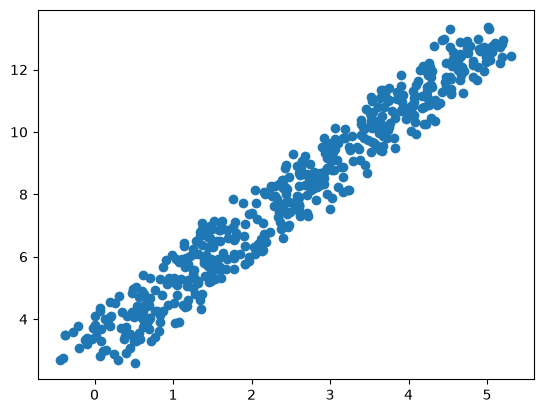

In [14]:
plt.plot(x,y,"o")
plt.show()

## 数据处理

1.x，y值放在一起

2.数据集分别为训练集和测试集

In [17]:
x = np.array(x)
y = np.array(y)

In [18]:
x.shape

(500,)

### 创建二维数据集

In [20]:
# 方法1
x = x.reshape(-1,1)
y = y.reshape(-1,1)
all_data = np.concatenate((x,y),axis=1)
print(all_data[:5])

[[ 4.17413979 11.14309618]
 [ 3.03079564  7.88052041]
 [ 0.67337361  4.4050014 ]
 [ 2.92547025  9.82118123]
 [-0.01427994  3.73077003]]


In [21]:
# 方法2
x = x.reshape(-1,)
y = y.reshape(-1,)
all_data = np.array([x,y]).T
print(all_data.shape)
print(all_data[:5])

(500, 2)
[[ 4.17413979 11.14309618]
 [ 3.03079564  7.88052041]
 [ 0.67337361  4.4050014 ]
 [ 2.92547025  9.82118123]
 [-0.01427994  3.73077003]]


### 创建测试训练集

In [22]:
train_data = all_data[:-64]
test_data = all_data[-64:]


## 数据分块

In [23]:
# 生成器
def gen_batch(data):
    for i in range(len(data) // 64):
        cursor = i * 64
        batch_data = data[cursor:cursor+64]
        x = batch_data[:,0]
        y = batch_data[:,1]
        yield x,y


In [24]:
g_gatch = gen_batch(train_data)
g_gatch

<generator object gen_batch at 0x000001AE418E8D40>

In [26]:
for x_,y_ in gen_batch(train_data):
    print(x_.shape,y_.shape)
    print("________")


(64,) (64,)
________
(64,) (64,)
________
(64,) (64,)
________
(64,) (64,)
________
(64,) (64,)
________
(64,) (64,)
________


### 超参数

In [28]:
learning_rate = 0.01
num_train_epochs = 100
display_step = 50

### 计算图

In [29]:
graph = tf.Graph()
with graph.as_default():
    x = tf.placeholder(shape=[None], dtype=tf.float32, name='x')
    y = tf.placeholder(shape=[None], dtype=tf.float32, name='y')

    w = tf.Variable(0.5, dtype=tf.float32, name='w')
    b = tf.Variable(0.2, dtype=tf.float32, name='b')
    
    y_pred = w * x + b
    loss = tf.reduce_mean(tf.square(y_pred - y))
    # 定义优化器
    optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate)
    train_step = optimizer.minimize(loss)


### 运行计算图

In [34]:
with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    step = 0
    for epoch in range(num_train_epochs):
        for x_,y_ in gen_batch(train_data):
            step += 1
            _,loss_value = sess.run([train_step,loss], feed_dict={x: x_, y: y_})
            if step%display_step == 0:
                w_value,b_value = sess.run([w,b])
                print(f'Epoch {epoch}, Step {step}, w: {w_value:.4f}, b: {b_value:.4f}, Loss: {loss_value:.4f}')
    print('Training completed')
    x_test,y_test = next(gen_batch(test_data))
    loss_test = sess.run(loss,{x: x_test, y: y_test})
    print(f'Loss on test data: {loss_test:.4f}')
    w_value,b_value = sess.run([w,b])
    print(f'w: {w_value:.4f}, b: {b_value:.4f}')
    


Epoch 8, Step 50, w: 2.4789, b: 1.3524, Loss: 1.1938
Epoch 16, Step 100, w: 2.3497, b: 1.7557, Loss: 1.0403
Epoch 24, Step 150, w: 2.2535, b: 2.0733, Loss: 0.6946
Epoch 33, Step 200, w: 2.1883, b: 2.3255, Loss: 0.5701
Epoch 41, Step 250, w: 2.1207, b: 2.5177, Loss: 0.5362
Epoch 49, Step 300, w: 2.0730, b: 2.6699, Loss: 0.4418
Epoch 58, Step 350, w: 2.0483, b: 2.7943, Loss: 0.4072
Epoch 66, Step 400, w: 2.0104, b: 2.8848, Loss: 0.4274
Epoch 74, Step 450, w: 1.9860, b: 2.9573, Loss: 0.3995
Epoch 83, Step 500, w: 1.9808, b: 3.0202, Loss: 0.3607
Epoch 91, Step 550, w: 1.9573, b: 3.0617, Loss: 0.4062
Epoch 99, Step 600, w: 1.9441, b: 3.0958, Loss: 0.3976
Training completed
Loss on test data: 0.3458
w: 1.9441, b: 3.0958


## 练习

使用下面函数构造训练数据，实现线性回归

    def pre(x):
        return 2.5*x+4

In [53]:
np.random.seed(42)
def pre(x):
    return 2.5 * x + 4

def gen_batch(data,batch_size=100):
    np.random.shuffle(data)
    for i in range(0,len(data),batch_size):
        yield data[i:i+batch_size][:,0],data[i:i+batch_size][:,1]

x = np.random.rand(20000)
y = [pre(i) for i in x]

# x = [i-0.3 + np.random.random(1)[0] for i in x]
# y = [i-0.3 + np.random.random(1)[0] for i in y]

x = np.array(x)
y = np.array(y)

x = x.reshape(-1,1)
y = y.reshape(-1,1)

all_data = np.concatenate((x,y),axis=1)

train_data = all_data[:16000]
test_data = all_data[16000:]

learning_rate = 0.01
num_epochs = 1000
batch_size = 64
display_step = 100

graph = tf.Graph()
with graph.as_default():
    x = tf.placeholder(shape=[None], dtype=tf.float32, name='x')
    y = tf.placeholder(shape=[None], dtype=tf.float32, name='y')

    w = tf.Variable(0.5, dtype=tf.float32, name='w')
    b = tf.Variable(0.2, dtype=tf.float32, name='b')
    
    y_pred = w * x + b
    loss = tf.reduce_mean(tf.square(y_pred - y))

    optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate)
    train_step = optimizer.minimize(loss)

with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    for epoch in range(num_epochs):
        for x_input,y_input in gen_batch(train_data,batch_size=batch_size):
            _,loss_value = sess.run([train_step,loss], feed_dict={x: x_input, y: y_input})
        if epoch % display_step == 0:
            w_value,b_value = sess.run([w,b])
            print(f'Epoch {epoch}, Loss: {loss_value:.4f} w: {w_value:.4f} b: {b_value:.4f}')
    print('Training completed')
    loss_value = sess.run(loss,feed_dict={x: test_data[:,0], y: test_data[:,1]})
    print(f'Test Loss: {loss_value:.4f}, w: {w_value:.4f}, b: {b_value:.4f}')
    




Epoch 0, Loss: 0.0001 w: 2.5002 b: 3.9918
Epoch 100, Loss: 0.0000 w: 2.5000 b: 4.0000
Epoch 200, Loss: 0.0000 w: 2.5000 b: 4.0000
Epoch 300, Loss: 0.0000 w: 2.5000 b: 4.0000
Epoch 400, Loss: 0.0000 w: 2.5000 b: 4.0000
Epoch 500, Loss: 0.0000 w: 2.5000 b: 4.0000
Epoch 600, Loss: 0.0000 w: 2.5000 b: 4.0000
Epoch 700, Loss: 0.0000 w: 2.5000 b: 4.0000
Epoch 800, Loss: 0.0000 w: 2.5000 b: 4.0000
Epoch 900, Loss: 0.0000 w: 2.5000 b: 4.0000
Training completed
Test Loss: 0.0000, w: 2.5000, b: 4.0000
